In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


In [2]:

uploaded = files.upload()
image_path = list(uploaded.keys())[0]
print("Uploaded image:", image_path)

Saving anaar.png to anaar.png
Uploaded image: anaar.png


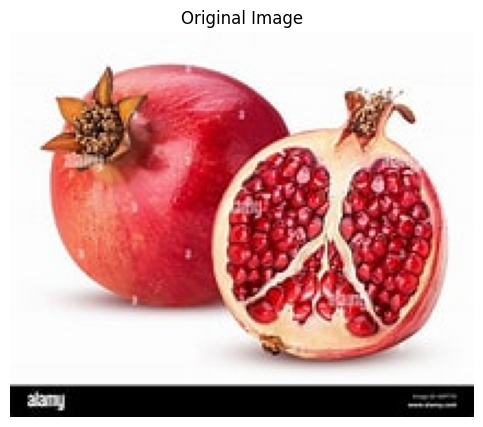

Image shape: (176, 212, 3)


In [3]:

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise ValueError("Image could not be loaded.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,5))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

print("Image shape:", img_rgb.shape)


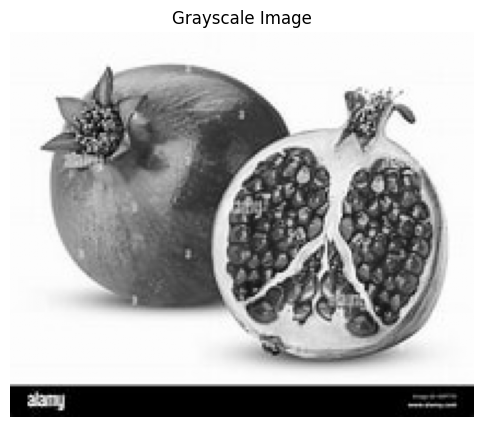

In [4]:

gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(7,5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

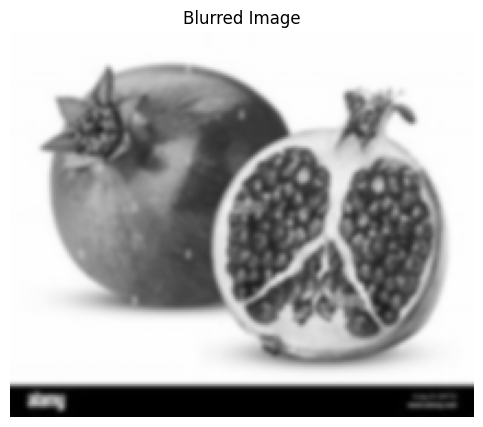

In [5]:

blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(7,5))
plt.imshow(blur, cmap="gray")
plt.title("Blurred Image")
plt.axis("off")
plt.show()

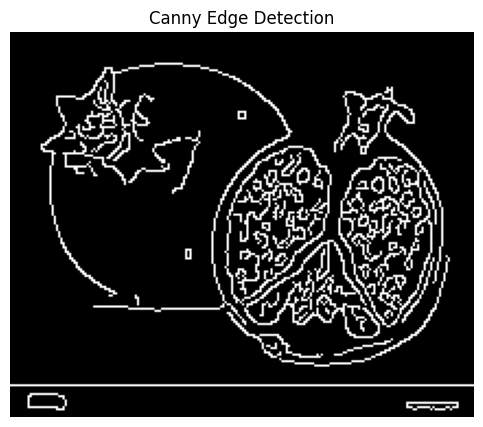

In [6]:
low_threshold = 100
high_threshold = 200

edges = cv2.Canny(blur, low_threshold, high_threshold)

plt.figure(figsize=(7,5))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

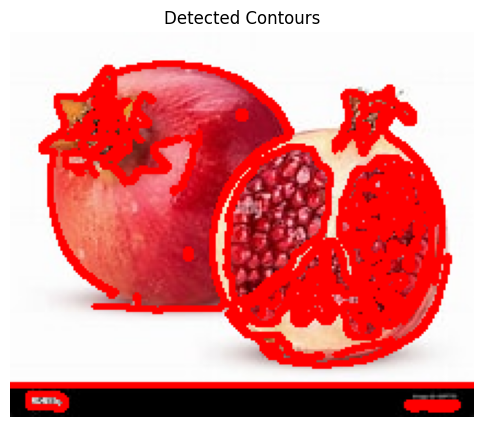

Total contours detected: 39


In [7]:
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img_rgb.copy()
cv2.drawContours(output, contours, -1, (255, 0, 0), 2)

plt.figure(figsize=(7,5))
plt.imshow(output)
plt.title("Detected Contours")
plt.axis("off")
plt.show()

print("Total contours detected:", len(contours))

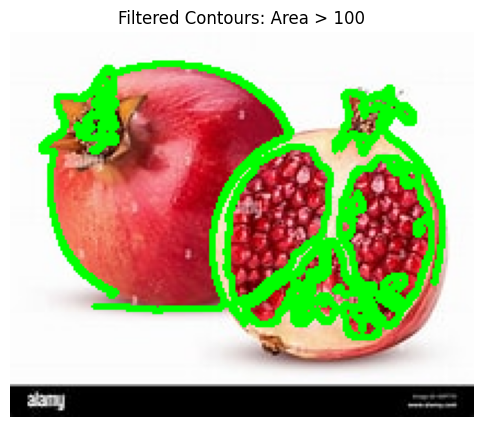

Filtered object count: 4


In [8]:
min_area = 100

filtered_contours = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > min_area:
        filtered_contours.append(cnt)

filtered_output = img_rgb.copy()
cv2.drawContours(filtered_output, filtered_contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(7,5))
plt.imshow(filtered_output)
plt.title(f"Filtered Contours: Area > {min_area}")
plt.axis("off")
plt.show()

print("Filtered object count:", len(filtered_contours))


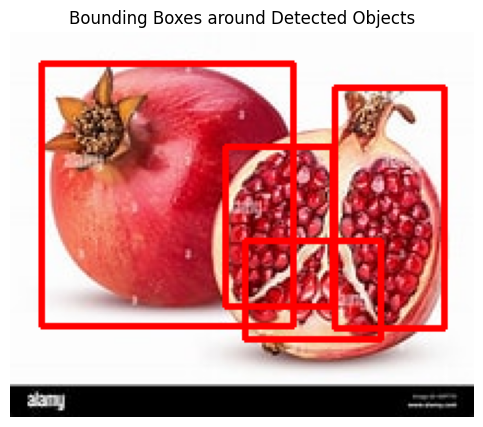

In [9]:

box_output = img_rgb.copy()

for cnt in filtered_contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(box_output, (x, y), (x+w, y+h), (255, 0, 0), 2)

plt.figure(figsize=(7,5))
plt.imshow(box_output)
plt.title("Bounding Boxes around Detected Objects")
plt.axis("off")
plt.show()

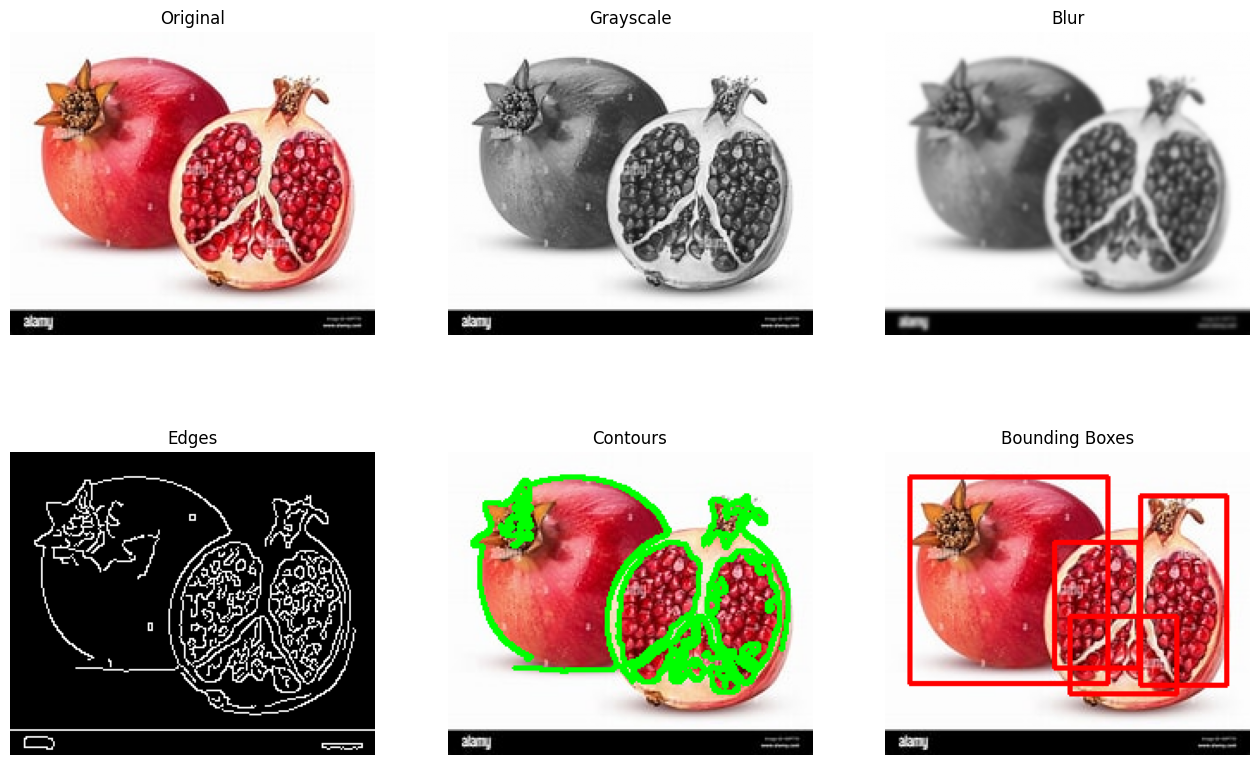

In [10]:
plt.figure(figsize=(16,10))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(blur, cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(filtered_output)
plt.title("Contours")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(box_output)
plt.title("Bounding Boxes")
plt.axis("off")

plt.show()
